In [9]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
from bordas import det_roberts, det_prewitt, det_sobel, det_scharr, det_laplaciano, det_LoG, det_DoG, det_canny

In [10]:
# Carregar imagem
estrada_bgr = cv.imread('data/estrada.png')

In [11]:
# Implementação Opencv
estrada_manual_roberts = det_roberts(estrada_bgr)

# Implementação OpenCV (simulando Roberts com filter2D)
gray = cv.cvtColor(estrada_bgr, cv.COLOR_BGR2GRAY).astype(np.float64)
kernel_gx = np.array([[1, 0], [0, -1]], dtype=np.float64)
kernel_gy = np.array([[0, 1], [-1, 0]], dtype=np.float64)

gx = cv.filter2D(gray, -1, kernel_gx)
gy = cv.filter2D(gray, -1, kernel_gy)
magnitude = np.sqrt(gx ** 2 + gy ** 2)
estrada_opencv_roberts = cv.normalize(magnitude, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

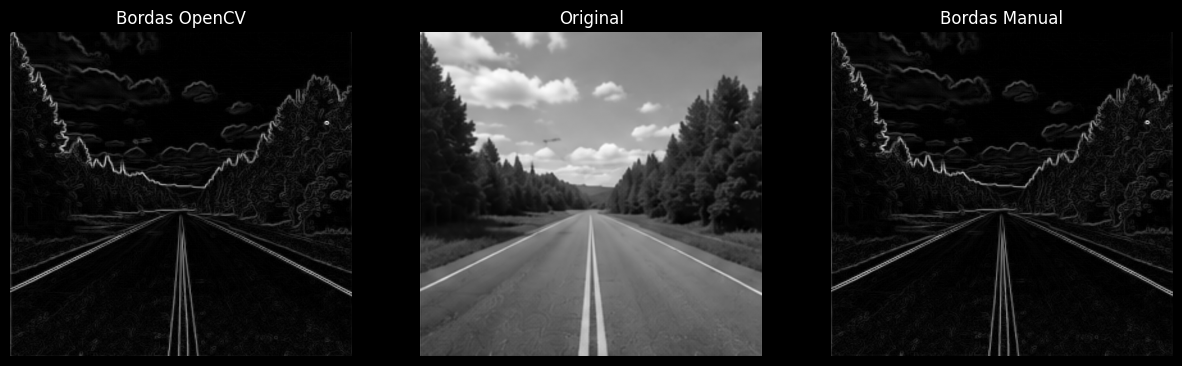

In [12]:
# Exibição em Grayscale

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title('Bordas OpenCV')
plt.imshow(estrada_opencv_roberts, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Original')
estrada_gray = cv.cvtColor(estrada_bgr, cv.COLOR_BGR2GRAY)
plt.imshow(estrada_gray, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Bordas Manual')
plt.imshow(estrada_manual_roberts, cmap='gray')
plt.axis('off')

plt.show()


In [13]:
# Implementação Manual
estrada_manual_prewitt = det_prewitt(estrada_bgr)

# Implementação OpenCV usando filter2D
gray = cv.cvtColor(estrada_bgr, cv.COLOR_BGR2GRAY).astype(np.float32)

kernel_gx = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

kernel_gy = np.array([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1]
], dtype=np.float32)

gx = cv.filter2D(gray, -1, kernel_gx)
gy = cv.filter2D(gray, -1, kernel_gy)

magnitude = np.sqrt(gx ** 2 + gy ** 2)

estrada_opencv_prewitt = cv.normalize(
    magnitude, None, 0, 255, cv.NORM_MINMAX
).astype(np.uint8)

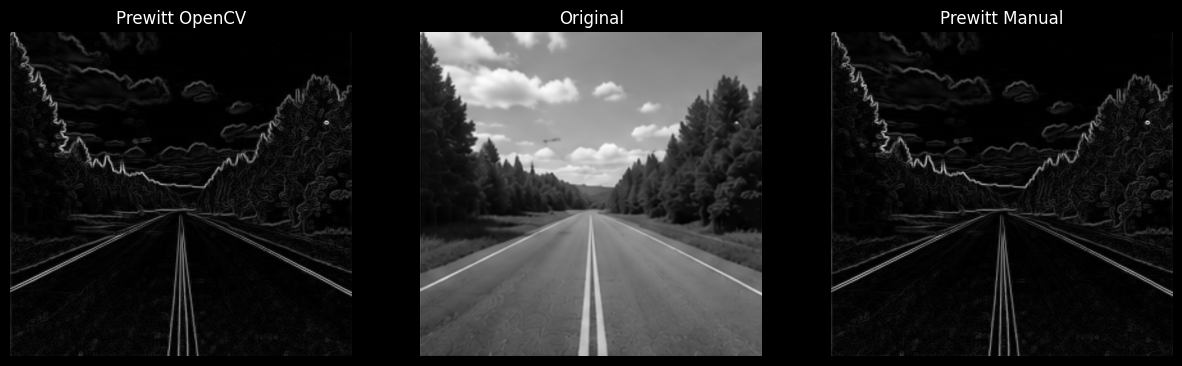

In [14]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title('Prewitt OpenCV')
plt.imshow(estrada_opencv_prewitt, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Original')
estrada_gray = cv.cvtColor(estrada_bgr, cv.COLOR_BGR2GRAY)
plt.imshow(estrada_gray, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Prewitt Manual')
plt.imshow(estrada_manual_prewitt, cmap='gray')
plt.axis('off')

plt.show()